<a href="https://colab.research.google.com/github/raimar/Datathon-FIAP/blob/main/DATATHON_PASSOS_MAGICOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Datathon FIAP — Passos Mágicos
## Análise 2022–2024 e Modelo Preditivo de Risco de Defasagem

Alunos:

Luis Gustavo e
Raimar Modesto

Este notebook parte da planilha já tratada e consolidada e cobre:

1. Ingestão e validação
2. Padronização/qualidade
3. Consolidação por `ano_referencia`
4. Respostas às perguntas do Datathon
5. Modelo de Machine Learning para risco de piora da defasagem
6. Efetividade do programa / Pedras
7. Insights adicionais

> **Definição do alvo preditivo:** um aluno entra em risco quando sua `defasagem` no ano seguinte é menor que a do ano atual.  
> Exemplo: `0 → -1`, `-1 → -2` ou `-2 → -3`.


## 1. Bibliotecas

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42


## 2. Ingestão no Google Colab

Faça upload do arquivo **BASE DATATHON - TRATADA.xlsx**.


In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
# O arquivo está na pasta /content/
ARQUIVO = '/content/BASE DATATHON - TRATADA.xlsx'
print("Arquivo carregado:", ARQUIVO)

xls = pd.ExcelFile(ARQUIVO)
print("Abas:", xls.sheet_names)

Arquivo carregado: /content/BASE DATATHON - TRATADA.xlsx
Abas: ['PEDE2022', 'PEDE2023', 'PEDE2024', 'CONSOLIDADA', 'QUALIDADE']


## 3. Leitura da base consolidada

In [36]:
base = pd.read_excel(ARQUIVO, sheet_name="CONSOLIDADA")
print("Dimensão:", base.shape)
display(base.head())

Dimensão: (3030, 44)


,ano_referencia,ra,nome,numero,nome-numero,data_nascimento,ano_nascimento,idade,genero,ano_ingresso,anos_na_pm,fase,turma,fase_ideal,instituicao_ensino,escola,situacao,pedra,inde,ian,ida,ieg,iaa,ips,ipp,ipv,matematica,portugues,ingles,defasagem,faixa_defasagem,em_defasagem,defasagem_severa,indicado,atingiu_pv,atingiu_pv_bin,destaque_ieg,destaque_ida,destaque_ipv,cg,cf,ct,numero_avaliadores,recomendacao_psicologia
0,2024,RA-153,Aluno,153,Aluno-153,2008-08-15 00:00:00,2008,16,Feminino,2021,3,7.0,7E,5,Bolsista/Privada,Colégio Albert Einstein - SP,Cursando,Quartzo,4.78185,10.0,0.0,0.0,8.751,6.5675,7.5,7.5,0.0,0.0,0.0,2,Em fase,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,2024,RA-270,Aluno,270,Aluno-270,2009-02-28 00:00:00,2009,15,Feminino,2021,3,7.0,7E,5,Bolsista/Privada,Colégio Albert Einstein - SP,Cursando,Quartzo,4.79255,10.0,0.0,0.0,9.168,6.2575,7.5,7.5,0.0,0.0,0.0,2,Em fase,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2,2024,RA-1227,Aluno,1227,Aluno-1227,2006-11-15 00:00:00,2006,17,Feminino,2021,3,7.0,7E,7,Bolsista/Privada,Colégio Albert Einstein - SP,Cursando,Quartzo,4.84460,10.0,0.0,0.0,8.751,7.1950,7.5,7.5,0.0,0.0,0.0,0,Em fase,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
3,2024,RA-1228,Aluno,1228,Aluno-1228,2006-05-26 03:00:00,2006,18,Feminino,2021,3,7.0,7E,7,Bolsista/Privada,Colégio Albert Einstein - SP,Cursando,Quartzo,4.87610,10.0,0.0,0.0,8.751,7.5100,7.5,7.5,0.0,0.0,0.0,0,Em fase,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
4,2024,RA-1229,Aluno,1229,Aluno-1229,2006-12-07 00:00:00,2006,17,Feminino,2021,3,7.0,7E,7,Bolsista/Privada,Colégio Albert Einstein - SP,Cursando,Quartzo,4.82380,10.0,0.0,0.0,9.168,6.5700,7.5,7.5,0.0,0.0,0.0,0,Em fase,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


## 4. Validação da qualidade

In [37]:
print("Registros por ano:")
display(base.groupby("ano_referencia").size().rename("linhas"))

print("\nRA únicos por ano:")
display(base.groupby("ano_referencia")["ra"].nunique().rename("ra_unicos"))

duplicados = base.duplicated(["ano_referencia", "ra"]).sum()
print("\nDuplicados ano + RA:", duplicados)

campos_chave = [
    "inde","ian","ida","ieg","iaa","ips","ipp","ipv",
    "defasagem","pedra","fase","fase_ideal"
]
qualidade = (
    base.groupby("ano_referencia")[campos_chave]
        .apply(lambda x: (x.isna().mean()*100).round(2))
)
display(qualidade)


Registros por ano:


,linhas
ano_referencia,
2022,860
2023,1014
2024,1156



RA únicos por ano:


,ra_unicos
ano_referencia,
2022,860
2023,1014
2024,1156



Duplicados ano + RA: 0


,inde,ian,ida,ieg,iaa,ips,ipp,ipv,defasagem,pedra,fase,fase_ideal
ano_referencia,,,,,,,,,,,,
2022,0.00,0.0,0.00,0.0,0.00,0.00,100.00,0.00,0.0,0.00,0.00,0.0
2023,8.19,0.0,7.59,7.5,6.21,6.80,7.50,10.06,0.0,8.19,22.78,0.0
2024,8.82,0.0,8.74,0.0,19.38,8.82,8.82,8.82,0.0,5.54,16.96,0.0


### Observação importante sobre IPP
Em 2022 o campo `ipp` está integralmente nulo. Isso impede que ele seja usado de forma confiável em uma validação temporal treinando 2022 e testando 2023. O IPP continua nas análises descritivas de 2023/2024, mas é retirado da versão principal do modelo temporal.


## 5. Visão geral 2022–2024

In [38]:
resumo_ano = base.groupby("ano_referencia").agg(
    alunos=("ra","nunique"),
    inde_medio=("inde","mean"),
    ian_medio=("ian","mean"),
    ida_medio=("ida","mean"),
    ieg_medio=("ieg","mean"),
    iaa_medio=("iaa","mean"),
    ips_medio=("ips","mean"),
    ipv_medio=("ipv","mean"),
    defasagem_media=("defasagem","mean"),
    pct_em_defasagem=("em_defasagem","mean")
)
resumo_ano["pct_em_defasagem"] *= 100
display(resumo_ano.round(2))


,alunos,inde_medio,ian_medio,ida_medio,ieg_medio,iaa_medio,ips_medio,ipv_medio,defasagem_media,pct_em_defasagem
ano_referencia,,,,,,,,,,
2022,860,7.04,6.42,6.09,7.89,8.27,6.90,7.25,-0.94,69.88
2023,1014,7.34,7.24,6.66,8.70,6.90,5.12,7.97,-0.65,54.44
2024,1156,7.40,7.68,6.35,7.37,8.35,6.83,7.35,-0.41,46.19


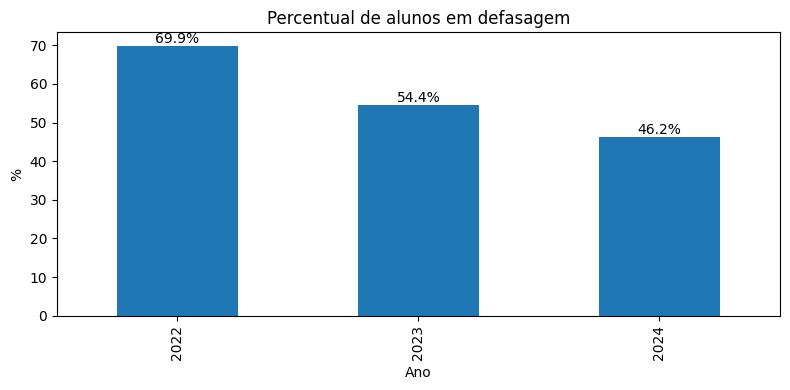

In [39]:
ax = resumo_ano["pct_em_defasagem"].plot(kind="bar", figsize=(8,4))
ax.set_title("Percentual de alunos em defasagem")
ax.set_xlabel("Ano")
ax.set_ylabel("%")
ax.bar_label(ax.containers[0], fmt="%.1f%%")
plt.tight_layout()
plt.show()


## 6. Pergunta 1 — Adequação de nível (IAN) / Defasagem

faixa_defasagem,Em fase,Moderada,Severa
ano_referencia,,,
2022,30.1,47.7,22.2
2023,45.6,40.2,14.2
2024,53.8,38.1,8.0


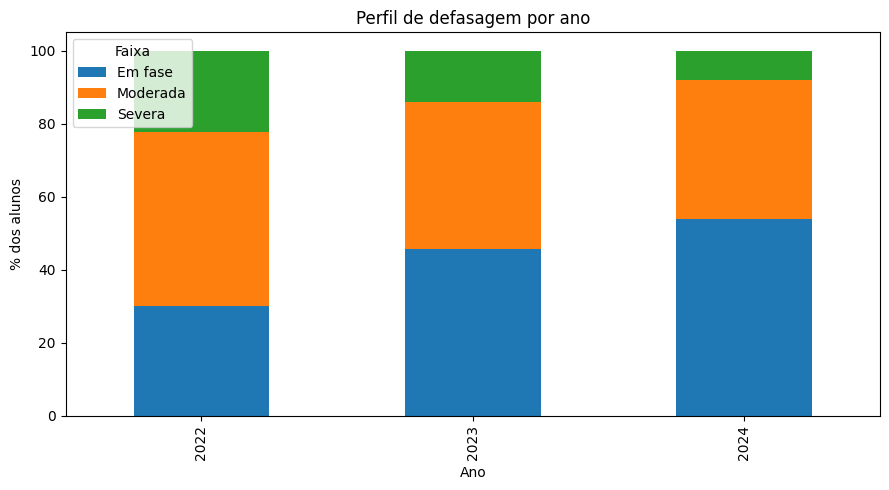

In [40]:
dist_def = pd.crosstab(
    base["ano_referencia"],
    base["faixa_defasagem"],
    normalize="index"
).mul(100).round(1)

display(dist_def)

dist_def.plot(kind="bar", stacked=True, figsize=(9,5))
plt.title("Perfil de defasagem por ano")
plt.xlabel("Ano")
plt.ylabel("% dos alunos")
plt.legend(title="Faixa")
plt.tight_layout()
plt.show()


**Leitura esperada:** a participação de alunos moderada ou severamente defasados diminui ao longo dos três anos, enquanto cresce o grupo classificado como “Em fase”.


## 7. Pergunta 2 — Desempenho acadêmico (IDA)

,ida
ano_referencia,
2022,6.09
2023,6.66
2024,6.35


pedra,Ametista,Incluir,Quartzo,Topázio,Ágata
ano_referencia,,,,,
2022,7.01,NaN,3.14,8.25,5.25
2023,6.87,NaN,4.59,8.13,5.59
2024,6.57,NaN,3.11,8.19,4.92


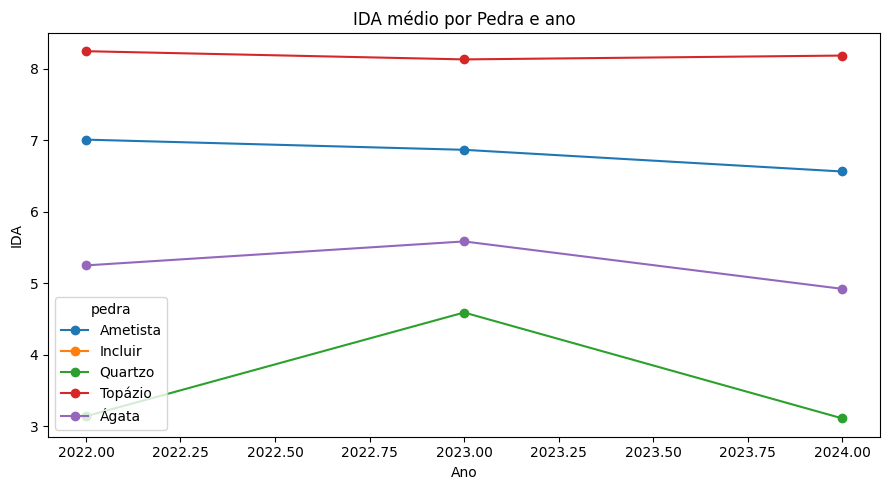

In [41]:
ida_ano = base.groupby("ano_referencia")["ida"].mean()
ida_pedra = base.groupby(["ano_referencia","pedra"])["ida"].mean().unstack()

display(ida_ano.round(2))
display(ida_pedra.round(2))

ida_pedra.plot(marker="o", figsize=(9,5))
plt.title("IDA médio por Pedra e ano")
plt.ylabel("IDA")
plt.xlabel("Ano")
plt.tight_layout()
plt.show()


## 8. Pergunta 3 — Relação IEG × IDA × IPV

In [42]:
for ano, df in base.groupby("ano_referencia"):
    print(f"\nAno {ano}")
    display(df[["ieg","ida","ipv"]].corr().round(3))



Ano 2022


,ieg,ida,ipv
ieg,1.000,0.564,0.589
ida,0.564,1.000,0.617
ipv,0.589,0.617,1.000



Ano 2023


,ieg,ida,ipv
ieg,1.000,0.461,0.441
ida,0.461,1.000,0.528
ipv,0.441,0.528,1.000



Ano 2024


,ieg,ida,ipv
ieg,1.000,0.538,0.535
ida,0.538,1.000,0.514
ipv,0.535,0.514,1.000


Há uma relação positiva consistente entre engajamento (`IEG`) e desempenho (`IDA`), e também entre engajamento e ponto de virada (`IPV`). Isso sugere que o engajamento é um indicador operacional importante para acompanhamento preventivo.


## 9. Pergunta 4 — Autoavaliação (IAA)

In [43]:
corr_iaa = []
for ano, df in base.groupby("ano_referencia"):
    corr_iaa.append({
        "ano": ano,
        "IAA_x_IDA": df[["iaa","ida"]].corr().iloc[0,1],
        "IAA_x_IEG": df[["iaa","ieg"]].corr().iloc[0,1],
    })
display(pd.DataFrame(corr_iaa).round(3))


,ano,IAA_x_IDA,IAA_x_IEG
0,2022,0.209,0.323
1,2023,0.105,0.170
2,2024,0.208,0.221


A correlação da autoavaliação com desempenho e engajamento é positiva, porém relativamente baixa. Portanto, a percepção do aluno sobre si mesmo não deve ser usada isoladamente para inferir seu desempenho real.


## 10. Pergunta 5 — Aspectos psicossociais (IPS)

In [44]:
corr_ips = []
for ano, df in base.groupby("ano_referencia"):
    corr_ips.append({
        "ano": ano,
        "IPS_x_IDA": df[["ips","ida"]].corr().iloc[0,1],
        "IPS_x_IEG": df[["ips","ieg"]].corr().iloc[0,1],
    })
display(pd.DataFrame(corr_ips).round(3))


,ano,IPS_x_IDA,IPS_x_IEG
0,2022,0.132,0.093
1,2023,0.132,0.045
2,2024,0.014,0.061


As correlações lineares contemporâneas do IPS com IDA e IEG são fracas. A hipótese de que fatores psicossociais **antecedem** quedas deve ser testada longitudinalmente, comparando o IPS atual com o desempenho do ano seguinte.


## 11. Construção da base longitudinal

In [45]:
atuais = [
    "ra","ano_referencia","idade","genero","anos_na_pm","fase","fase_ideal",
    "instituicao_ensino","pedra","inde","ian","ida","ieg","iaa","ips","ipp",
    "ipv","matematica","portugues","ingles","defasagem","em_defasagem"
]

corrente = base[atuais].copy()

proximo = base[
    ["ra","ano_referencia","defasagem","em_defasagem","faixa_defasagem",
     "ida","ieg","inde"]
].copy()

# Desloca o ano futuro para casar com o ano atual
proximo["ano_referencia"] = proximo["ano_referencia"] - 1

proximo = proximo.rename(columns={
    "defasagem":"defasagem_prox",
    "em_defasagem":"em_defasagem_prox",
    "faixa_defasagem":"faixa_defasagem_prox",
    "ida":"ida_prox",
    "ieg":"ieg_prox",
    "inde":"inde_prox"
})

painel = corrente.merge(proximo, on=["ra","ano_referencia"], how="inner")

painel["risco_piora"] = (
    painel["defasagem_prox"] < painel["defasagem"]
).astype(int)

painel["entra_defasagem"] = (
    (painel["defasagem"] >= 0) &
    (painel["defasagem_prox"] < 0)
).astype(int)

print("Transições disponíveis:", painel.shape[0])
display(
    painel.groupby("ano_referencia")["risco_piora"]
          .agg(["count","sum","mean"])
          .rename(columns={"mean":"taxa_risco"})
)


Transições disponíveis: 1365


,count,sum,taxa_risco
ano_referencia,,,
2022,600,104,0.173333
2023,765,132,0.172549


A base longitudinal contém as transições **2022→2023** e **2023→2024**. Isso permite testar causas antecedentes, reduzindo risco de *data leakage*.


## 12. Pergunta 5 — IPS antecede piora?

In [46]:
display(
    painel.groupby("risco_piora")[["ips","ida","ieg","iaa","ipv","inde","defasagem"]]
          .mean()
          .round(2)
)


,ips,ida,ieg,iaa,ipv,inde,defasagem
risco_piora,,,,,,,
0,5.91,6.72,8.62,7.66,7.83,7.36,-0.84
1,6.19,6.35,8.54,7.66,7.49,7.38,-0.17


## 13. Pergunta 6 — IPP × defasagem/IAN

In [47]:
for ano in [2023, 2024]:
    df = base[base["ano_referencia"] == ano]
    print(
        ano,
        "corr(IPP, IAN)=",
        round(df[["ipp","ian"]].corr().iloc[0,1], 3)
    )

display(
    base[base["ano_referencia"].isin([2023,2024])]
    .groupby(["ano_referencia","faixa_defasagem"])["ipp"]
    .mean()
    .unstack()
    .round(2)
)


2023 corr(IPP, IAN)= 0.095
2024 corr(IPP, IAN)= 0.154


faixa_defasagem,Em fase,Moderada,Severa
ano_referencia,,,
2023,7.67,7.65,7.04
2024,7.69,7.46,7.20


O IPP apresenta correlação linear fraca com IAN. Portanto, as avaliações psicopedagógicas não são simplesmente uma reprodução matemática da defasagem; elas agregam uma dimensão complementar.


## 14. Pergunta 7 — Fatores associados ao IPV

In [48]:
features_ipv = ["ida","ieg","iaa","ips","ipp","ian","inde"]
corr_ipv = base[features_ipv + ["ipv"]].corr()["ipv"].sort_values(ascending=False)
display(corr_ipv.round(3))


,ipv
ipv,1.000
inde,0.719
ipp,0.628
ieg,0.557
ida,0.553
ian,0.157
iaa,0.065
ips,-0.054


## 15. Pergunta 8 — O que mais eleva o INDE?

In [49]:
variaveis_inde = ["ida","ieg","ips","ipp","ipv","iaa","ian"]
display(
    base[variaveis_inde + ["inde"]]
    .corr()["inde"]
    .sort_values(ascending=False)
    .round(3)
)


,inde
inde,1.000
ida,0.785
ieg,0.745
ipv,0.719
ipp,0.540
ian,0.405
iaa,0.396
ips,0.200


## 16. Modelo preditivo — risco de piora da defasagem

### Estratégia de validação
Para simular uso real:

- **Treino:** indicadores de 2022 → resultado observado em 2023.
- **Teste:** indicadores de 2023 → resultado observado em 2024.

Isso é mais rigoroso que uma divisão aleatória, pois o modelo só é avaliado em um período futuro.


In [50]:
features_num = [
    "idade","anos_na_pm","fase","fase_ideal",
    "inde","ian","ida","ieg","iaa","ips","ipv",
    "matematica","portugues","ingles","defasagem"
]

features_cat = [
    "genero","instituicao_ensino","pedra"
]

treino = painel[painel["ano_referencia"] == 2022].copy()
teste  = painel[painel["ano_referencia"] == 2023].copy()

X_train = treino[features_num + features_cat]
y_train = treino["risco_piora"]

X_test = teste[features_num + features_cat]
y_test = teste["risco_piora"]

preprocessador = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), features_num),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), features_cat)
])


In [51]:
modelos = {
    "Regressão Logística": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

resultados = {}

for nome, modelo in modelos.items():
    pipe = Pipeline([
        ("preprocessador", preprocessador),
        ("modelo", modelo)
    ])

    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:,1]
    pred = (prob >= 0.50).astype(int)

    resultados[nome] = {
        "modelo": pipe,
        "prob": prob,
        "pred": pred,
        "roc_auc": roc_auc_score(y_test, prob),
        "pr_auc": average_precision_score(y_test, prob)
    }

    print("\n", "="*60)
    print(nome)
    print("ROC-AUC:", round(resultados[nome]["roc_auc"], 3))
    print("PR-AUC :", round(resultados[nome]["pr_auc"], 3))
    print(classification_report(y_test, pred, digits=3))



Regressão Logística
ROC-AUC: 0.811
PR-AUC : 0.467
              precision    recall  f1-score   support

           0      0.905     0.847     0.875       633
           1      0.439     0.576     0.498       132

    accuracy                          0.800       765
   macro avg      0.672     0.711     0.687       765
weighted avg      0.825     0.800     0.810       765


Random Forest
ROC-AUC: 0.855
PR-AUC : 0.57
              precision    recall  f1-score   support

           0      0.910     0.889     0.899       633
           1      0.521     0.576     0.547       132

    accuracy                          0.835       765
   macro avg      0.715     0.733     0.723       765
weighted avg      0.842     0.835     0.839       765



Na validação temporal inicial desta base, o **Random Forest** apresentou desempenho superior à regressão logística e é o candidato principal para a aplicação.


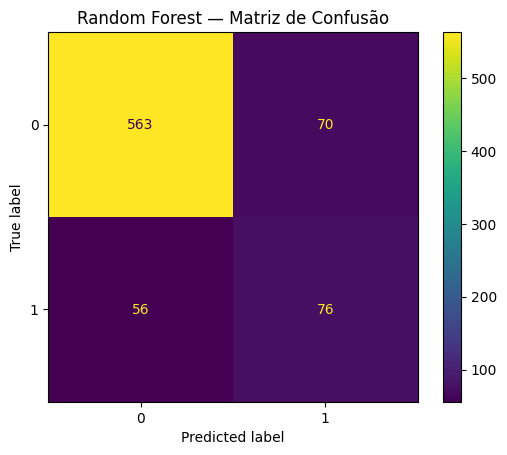

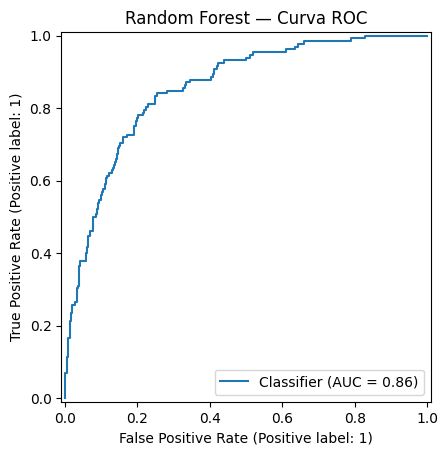

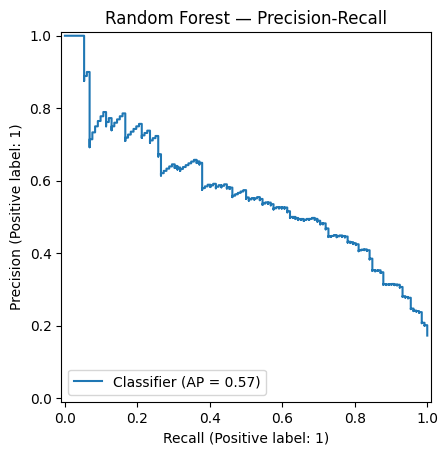

In [52]:
melhor = resultados["Random Forest"]["modelo"]
prob = resultados["Random Forest"]["prob"]
pred = resultados["Random Forest"]["pred"]

ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("Random Forest — Matriz de Confusão")
plt.show()

RocCurveDisplay.from_predictions(y_test, prob)
plt.title("Random Forest — Curva ROC")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, prob)
plt.title("Random Forest — Precision-Recall")
plt.show()


## 17. Importância das variáveis

,variavel,importancia
0,idade,0.048174
14,defasagem,0.028174
5,ian,0.025953
10,ipv,0.019180
3,fase_ideal,0.010251
6,ida,0.010164
12,portugues,0.007481
11,matematica,0.005416
1,anos_na_pm,0.004788
2,fase,0.003498


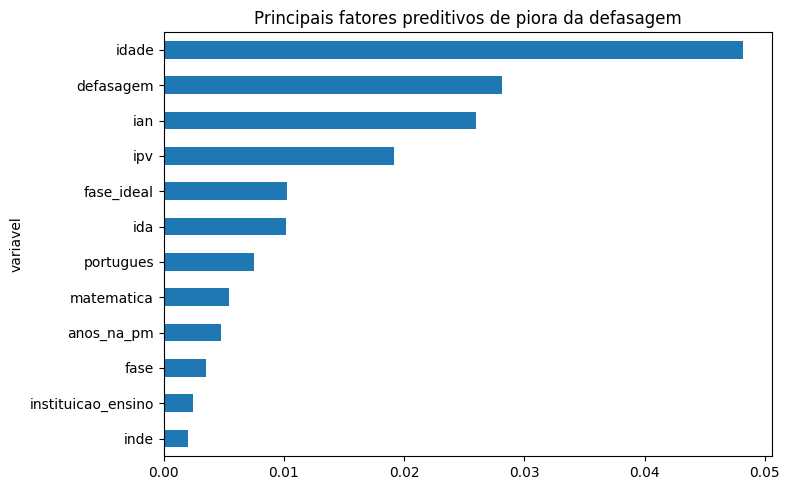

In [53]:
# Permutation importance no conjunto de teste (variáveis originais)
perm = permutation_importance(
    melhor,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importancias = (
    pd.DataFrame({
        "variavel": X_test.columns,
        "importancia": perm.importances_mean
    })
    .sort_values("importancia", ascending=False)
)

display(importancias.head(15))

importancias.head(12).sort_values("importancia").plot(
    x="variavel", y="importancia", kind="barh", figsize=(8,5), legend=False
)
plt.title("Principais fatores preditivos de piora da defasagem")
plt.tight_layout()
plt.show()


## 18. Efetividade do programa — Pedras

In [54]:
pedras = (
    base[base["pedra"].isin(["Quartzo","Ágata","Ametista","Topázio"])]
    .groupby(["ano_referencia","pedra"])
    [["inde","ida","ieg","ips","ipv","defasagem"]]
    .mean()
    .round(2)
)
display(pedras)


inde   ida   ieg   ips   ipv  defasagem
ano_referencia pedra                                            
2022           Ametista  7.53  7.01  8.62  7.07  7.63      -0.84
               Quartzo   5.24  3.14  5.26  6.55  5.80      -1.46
               Topázio   8.37  8.25  9.28  7.35  8.43      -0.34
               Ágata     6.61  5.25  7.54  6.63  6.89      -1.13
2023           Ametista  7.51  6.87  8.95  4.96  8.11      -0.64
               Quartzo   5.55  4.59  7.12  4.13  6.86      -1.36
               Topázio   8.44  8.13  9.43  6.20  8.70      -0.29
               Ágata     6.57  5.59  8.10  4.69  7.47      -1.06
2024           Ametista  7.53  6.57  8.46  6.94  7.44      -0.56
               Quartzo   5.40  3.11  5.04  5.96  5.84      -0.89
               Topázio   8.47  8.19  9.40  7.09  8.22      -0.04
               Ágata     6.60  4.92  7.07  6.70  6.71      -0.80

A hierarquia das Pedras é bastante consistente: **Topázio** concentra os maiores níveis médios de INDE/IDA/IEG/IPV e menor defasagem; **Quartzo** concentra os menores resultados. A evidência mais forte de efetividade, porém, deve vir da evolução dos **mesmos alunos**, não apenas da comparação entre grupos em cada ano.


## 19. Evolução dos mesmos alunos

In [55]:
longitudinal = painel.groupby("ano_referencia").agg(
    alunos=("ra","nunique"),
    def_atual=("defasagem","mean"),
    def_ano_seguinte=("defasagem_prox","mean"),
    ida_atual=("ida","mean"),
    ida_ano_seguinte=("ida_prox","mean"),
    ieg_atual=("ieg","mean"),
    ieg_ano_seguinte=("ieg_prox","mean"),
    inde_atual=("inde","mean"),
    inde_ano_seguinte=("inde_prox","mean")
).round(3)

display(longitudinal)


,alunos,def_atual,def_ano_seguinte,ida_atual,ida_ano_seguinte,ieg_atual,ieg_ano_seguinte,inde_atual,inde_ano_seguinte
ano_referencia,,,,,,,,,
2022,600,-0.892,-0.735,6.467,6.603,8.301,8.556,7.263,7.236
2023,765,-0.590,-0.324,6.826,6.311,8.865,7.261,7.455,7.390


## 20. Insights adicionais

### Sugestões para o storytelling gerencial

1. **A defasagem está diminuindo:** o percentual de alunos em defasagem cai de forma relevante entre 2022 e 2024.
2. **Engajamento é um sinal operacional importante:** IEG mantém relação positiva com IDA e IPV.
3. **Autoavaliação não basta:** IAA tem associação relativamente baixa com desempenho real.
4. **O risco pode ser antecipado:** a base longitudinal permite prever piora antes do ano seguinte.
5. **Priorizar Recall no modelo:** para uma ONG educacional, deixar um aluno de risco sem alerta pode ser mais prejudicial que gerar alguns falsos positivos.
6. **Transformar a probabilidade em faixas:** Baixo, Moderado e Alto Risco para uso no Streamlit.
7. **Intervenção orientada por fatores:** além do score, mostrar os principais indicadores do aluno que contribuíram para o alerta.


## 21. Exportação de uma base para o Streamlit

In [56]:
# Modelo final poderá ser treinado depois com todas as transições rotuladas.
# Para a aplicação, a base mais recente (2024) será usada para gerar scores prospectivos.

base_2024 = base[base["ano_referencia"] == 2024].copy()
base_2024.to_csv("base_2024_streamlit.csv", index=False)
print("Arquivo gerado: base_2024_streamlit.csv")


Arquivo gerado: base_2024_streamlit.csv
